# Exercícios — Árvores de Decisão

**Tema:** Aprendizado Supervisionado › Árvores de Decisão

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.datasets import make_classification

rng = np.random.default_rng(1414)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — Calculando Gini na mão

Para um nó com 8 exemplos da classe A e 2 da classe B, calcule o Gini.
Depois calcule o Gini de um corte que separa perfeitamente (um filho só
com A, outro só com B). Confirme que o ganho de informação é positivo.

In [2]:
# --- sua resposta ---

### Gabarito 1

In [3]:
def gini(contagens):
    total = sum(contagens)
    proporcoes = [c / total for c in contagens]
    return 1 - sum(p**2 for p in proporcoes)


gini_pai = gini([8, 2])
gini_filho_a = gini([8, 0])
gini_filho_b = gini([0, 2])
ganho = gini_pai - (8/10 * gini_filho_a + 2/10 * gini_filho_b)

print(f"Gini do nó pai (8 vs 2): {gini_pai:.4f}")
print(f"Gini do filho A (8 vs 0): {gini_filho_a:.4f}")
print(f"Gini do filho B (0 vs 2): {gini_filho_b:.4f}")
print(f"ganho de informação do corte perfeito: {ganho:.4f}")

Gini do nó pai (8 vs 2): 0.3200
Gini do filho A (8 vs 0): 0.0000
Gini do filho B (0 vs 2): 0.0000
ganho de informação do corte perfeito: 0.3200


---
## Exercício 2 🟢 — Árvore de regressão do zero (critério de variância)

Adapte a função `ganho_de_informacao` do notebook-guia para regressão:
em vez de Gini, use a redução da soma de quadrados dos resíduos em torno
da média de cada filho. Teste em um `y` contínuo simples e confirme que o
corte escolhido faz sentido visualmente.

In [4]:
# --- sua resposta ---

### Gabarito 2

melhor limiar encontrado: 4.977  (esperado: perto de 5.0)
redução de soma de quadrados: 903.65


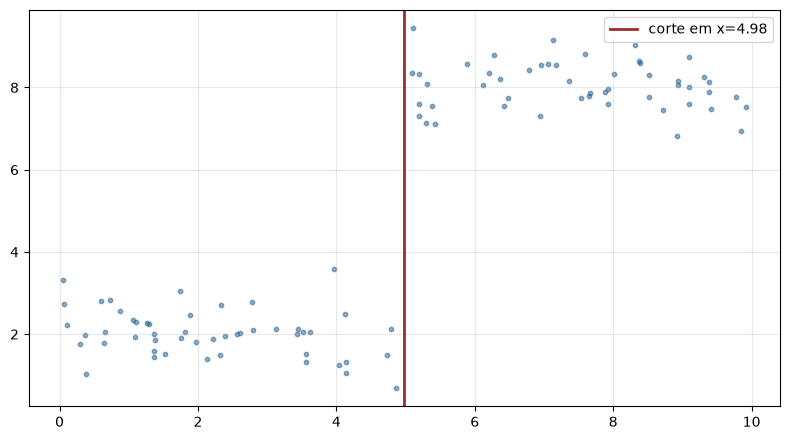

In [5]:
def soma_quadrados(y):
    if len(y) == 0:
        return 0.0
    return np.sum((y - y.mean()) ** 2)


def melhor_corte_regressao(x, y):
    melhor_reducao, melhor_limiar = -1, None
    valores_unicos = np.unique(x)
    limiares = (valores_unicos[:-1] + valores_unicos[1:]) / 2
    sq_pai = soma_quadrados(y)
    for limiar in limiares:
        mascara = x <= limiar
        reducao = sq_pai - (soma_quadrados(y[mascara]) + soma_quadrados(y[~mascara]))
        if reducao > melhor_reducao:
            melhor_reducao, melhor_limiar = reducao, limiar
    return melhor_limiar, melhor_reducao


x = np.concatenate([rng.uniform(0, 5, 50), rng.uniform(5, 10, 50)])
y = np.concatenate([rng.normal(2, 0.5, 50), rng.normal(8, 0.5, 50)])
limiar, reducao = melhor_corte_regressao(x, y)
print(f"melhor limiar encontrado: {limiar:.3f}  (esperado: perto de 5.0)")
print(f"redução de soma de quadrados: {reducao:.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(x, y, s=10, alpha=0.5, color=AZUL)
ax.axvline(limiar, color=VERMELHO, lw=2, label=f"corte em x={limiar:.2f}")
ax.legend(); plt.tight_layout(); plt.show()

---
## Exercício 3 🟡 — Medindo instabilidade de forma sistemática

Treine 40 árvores (`max_depth=2`) em amostras bootstrap do mesmo dataset.
Para cada árvore, registre qual feature foi usada no corte da raiz.
Reporte a distribuição de features escolhidas — quão "instável" é a
escolha da raiz?

In [6]:
# --- sua resposta ---

### Gabarito 3

feature escolhida na RAIZ, em 40 árvores bootstrap:
x0    33
x1     7


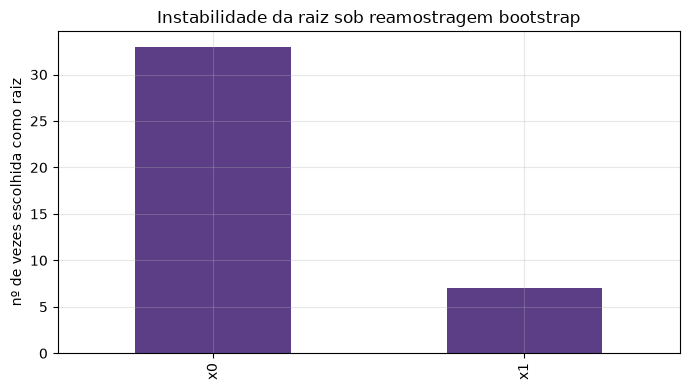

In [7]:
# duas features QUASE igualmente informativas (construídas a partir do
# mesmo fator latente z, com ruído independente) -- o cenário onde o
# algoritmo guloso mais hesita entre qual usar na raiz
n = 40
z = rng.normal(0, 1, n)
x0 = z + rng.normal(0, 0.5, n)
x1 = z + rng.normal(0, 0.5, n)
X = np.column_stack([x0, x1, rng.normal(0, 1, (n, 3))])
y = (z > 0).astype(int)

features_raiz = []
for i in range(40):
    idx = rng.integers(0, len(X), len(X))  # bootstrap
    modelo = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X[idx], y[idx])
    features_raiz.append(modelo.tree_.feature[0])  # feature usada no nó raiz

contagem = pd.Series(features_raiz).value_counts().sort_index()
contagem.index = [f"x{i}" for i in contagem.index]
print("feature escolhida na RAIZ, em 40 árvores bootstrap:")
print(contagem.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
contagem.plot(kind="bar", ax=ax, color=ROXO)
ax.set_ylabel("nº de vezes escolhida como raiz")
ax.set_title("Instabilidade da raiz sob reamostragem bootstrap")
plt.tight_layout(); plt.show()

**Resposta esperada:** se mais de uma feature aparece como raiz em
frações substanciais das 30 árvores, isso confirma a instabilidade do
`teoria.pdf` — pequenas mudanças na amostra (aqui, reamostragem
bootstrap) mudam a decisão mais fundamental da árvore. Esse é exatamente o
fenômeno que o Random Forest (próximo módulo) transforma em vantagem,
combinando muitas dessas árvores "instáveis".

---
## Exercício 4 🟡 — Comparando pré-poda e pós-poda em um dataset mais difícil

Usando um dataset com mais ruído (`flip_y=0.15` em `make_classification`),
compare o melhor resultado de pré-poda (grid search em `max_depth` e
`min_samples_leaf`) com pós-poda (`ccp_alpha` escolhido por CV). Ambos
devem ser validados sem espiar o conjunto de teste.

In [8]:
# --- sua resposta ---

### Gabarito 4

In [9]:
X, y = make_classification(n_samples=800, n_features=8, n_informative=5,
                           n_redundant=0, flip_y=0.15, random_state=4)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=0)

grade = {"max_depth": [2, 3, 4, 5, 7, None], "min_samples_leaf": [1, 5, 10, 20]}
busca_pre = GridSearchCV(DecisionTreeClassifier(random_state=0), grade, cv=5).fit(
    X_treino, y_treino)

caminho = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(
    X_treino, y_treino)
scores_pos = [cross_val_score(
    DecisionTreeClassifier(random_state=0, ccp_alpha=a), X_treino, y_treino, cv=5).mean()
    for a in caminho.ccp_alphas]
melhor_alpha = caminho.ccp_alphas[np.argmax(scores_pos)]
modelo_pos = DecisionTreeClassifier(random_state=0, ccp_alpha=melhor_alpha).fit(
    X_treino, y_treino)

print(f"pré-poda : {busca_pre.best_params_}   "
      f"acc teste={busca_pre.score(X_teste, y_teste):.4f}")
print(f"pós-poda : ccp_alpha={melhor_alpha:.5f}   "
      f"acc teste={modelo_pos.score(X_teste, y_teste):.4f}")

pré-poda : {'max_depth': 3, 'min_samples_leaf': 1}   acc teste=0.7833
pós-poda : ccp_alpha=0.01352   acc teste=0.7708


---
## Exercício 5 🔴 — Auditoria: quando a árvore "aprende" a ordem dos dados

Um colega nota que seu modelo tem desempenho ótimo no teste, mas péssimo
em produção. Investigando, você descobre que o dataset de treino estava
ordenado por data, e uma feature (`id_sequencial`) é só o número da linha.
Mostre como essa feature pode enganar uma árvore sem restrição, e o que
`max_depth`/`min_samples_leaf` fazem (ou não fazem) para evitar isso.

In [10]:
# --- sua resposta ---

### Gabarito 5

In [11]:
n_treino, n_teste = 700, 300
feature_real = rng.normal(0, 1, n_treino + n_teste)
# relação PROBABILÍSTICA (não determinística) -- há sobreposição real entre
# as classes, então uma feature espúria "ajuda" a decorar o treino
prob_y = 1 / (1 + np.exp(-1.2 * feature_real))
y = (rng.random(n_treino + n_teste) < prob_y).astype(int)

# TREINO: por coincidência da coleta, quem chegou com id baixo tende a ser
# classe 1 (padrão espúrio, sem causa real -- só um artefato de como os
# dados foram numerados nesse período).
y_treino_bruto = y[:n_treino].copy()
ordem_por_classe = np.argsort(y_treino_bruto + rng.normal(0, 0.35, n_treino))
id_treino = np.empty(n_treino)
id_treino[ordem_por_classe] = np.arange(n_treino)  # id baixo -> mais provável classe 1

# TESTE: o id é apenas sequencial, SEM NENHUMA relação com a classe --
# exatamente o que se espera de um identificador de verdade.
id_teste = np.arange(n_treino, n_treino + n_teste)

X_treino = np.column_stack([id_treino, feature_real[:n_treino]])
X_teste = np.column_stack([id_teste, feature_real[n_treino:]])
y_treino, y_teste = y[:n_treino], y[n_treino:]

modelo_com_id = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_treino, y_treino)
modelo_sem_id = DecisionTreeClassifier(max_depth=3, random_state=0).fit(
    X_treino[:, [1]], y_treino)

for nome, m, cols in [("COM id_sequencial", modelo_com_id, [0, 1]),
                      ("SEM id_sequencial", modelo_sem_id, [1])]:
    Xte = X_teste[:, cols] if len(cols) == 2 else X_teste[:, cols]
    print(f"{nome:<20s} importâncias={np.round(m.feature_importances_, 3)}   "
          f"acc treino={m.score(X_treino[:, cols], y_treino):.4f}   "
          f"acc teste={m.score(Xte, y_teste):.4f}")

print("\nrepetindo com profundidade limitada a 1 (a restrição MAIS agressiva possível):")
for max_d in [1, 2, 3, None]:
    m = DecisionTreeClassifier(max_depth=max_d, random_state=0).fit(X_treino, y_treino)
    print(f"  max_depth={str(max_d):<5s} acc treino={m.score(X_treino, y_treino):.4f}   "
          f"acc teste={m.score(X_teste, y_teste):.4f}")

COM id_sequencial    importâncias=[0.938 0.062]   acc treino=0.9514   acc teste=0.5067
SEM id_sequencial    importâncias=[1.]   acc treino=0.7343   acc teste=0.7367

repetindo com profundidade limitada a 1 (a restrição MAIS agressiva possível):
  max_depth=1     acc treino=0.9371   acc teste=0.4933
  max_depth=2     acc treino=0.9371   acc teste=0.4933
  max_depth=3     acc treino=0.9514   acc teste=0.5067
  max_depth=None  acc treino=1.0000   acc teste=0.5200


**Resposta esperada:** `id_sequencial` carrega um padrão espúrio real, mas
que só existe **dentro do treino** — no teste, ele é apenas um contador
sem relação com a classe. O modelo COM `id_sequencial` tende a ter
desempenho de teste pior que o modelo SEM essa feature, porque parte da
"capacidade de decisão" da árvore foi gasta em um padrão que não se
repete fora do treino. Limitar `max_depth` não resolve isso: em qualquer
profundidade, a árvore ainda pode escolher `id_sequencial` no primeiro
corte (é, de fato, uma boa divisão **dentro do treino**) — restringir a
capacidade do modelo reduz overfitting a RUÍDO aleatório, mas não protege
contra uma feature estruturalmente contaminada. A correção real é a do
tema 3: identificar e remover a feature problemática, não ajustar
hiperparâmetros de complexidade.

---
## Fechamento

- Gini e ganho de informação são cálculos mecânicos e verificáveis à mão —
  não há mistério na escolha de cada corte.
- O mesmo critério de "redução de impureza" se generaliza para regressão
  trocando Gini por redução de soma de quadrados.
- Instabilidade de árvores é mensurável: reamostragens bootstrap do mesmo
  dataset produzem raízes diferentes com frequência real, não hipotética.
- Limitar hiperparâmetros reduz overfitting, mas não substitui um pipeline
  de dados correto — uma feature espúria ainda pode enganar uma árvore
  "podada" se o problema for na preparação dos dados, não na capacidade do
  modelo.

→ Próximo módulo: **Bagging e Random Forest**, onde a instabilidade de
árvores individuais vira, coletivamente, uma vantagem.